In [ ]:
!wget https://github.com/ChanCheeKean/datasets/blob/main/images/basic_cv.zip?raw=true
!wget https://moderncomputervision.s3.eu-west-2.amazonaws.com/images.zip
!wget https://github.com/rajeevratan84/ModernComputerVision/raw/main/soaps.jpeg
!unzip -qq images.zip
!unzip -qq basic_cv.zip?raw=true

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans
from skimage.metrics import structural_similarity

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [6]:
def imshow(title="Image", image=None, size=8):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w / h
    plt.figure(figsize=(size * aspect_ratio, size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()


def display(img, cmap=None):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap)

# 1) Histrogram
Check out the video for full details, but here is also a great write-up: http://www.cambridgeincolour.com/tutorials/histograms1.htm

**cv2.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]])**
* images : it is the source image of type uint8 or float32. it should be given in square brackets, ie, “[img]”.
* channels : it is also given in square brackets. It is the index of channel for which we calculate histogram. For example, if input is grayscale image, its value is [0]. For color image, you can pass [0], [1] or [2] to calculate histogram of blue, green or red channel respectively.
* mask : mask image. To find histogram of full image, it is given as “None”. But if you want to find histogram of particular region of image, you have to create a mask image for that and give it as mask. (I will show an example later.)
* histSize : this represents our BIN count. Need to be given in square brackets. For full scale, we pass [256].
* ranges : this is our RANGE. Normally, it is [0,256].

## 1.1 Color Graph

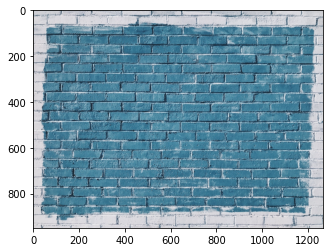

In [7]:
dark_horse = cv2.imread("./basic_cv/horse.jpg")
show_horse = cv2.cvtColor(dark_horse, cv2.COLOR_BGR2RGB)

rainbow = cv2.imread("./basic_cv/rainbow.jpg")
show_rainbow = cv2.cvtColor(rainbow, cv2.COLOR_BGR2RGB)

blue_bricks = cv2.imread("./basic_cv/bricks.jpg")
show_bricks = cv2.cvtColor(blue_bricks, cv2.COLOR_BGR2RGB)

plt.imshow(show_horse)
plt.imshow(show_rainbow)
plt.imshow(show_bricks)

(256, 1)


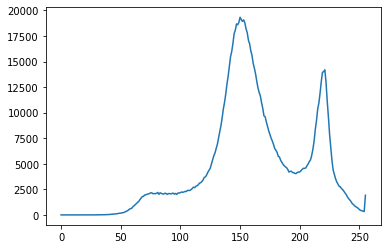

In [8]:
# test blue color
hist_values = cv2.calcHist(
    [blue_bricks], channels=[0], mask=None, histSize=[256], ranges=[0, 256]
)
print(hist_values.shape)
plt.plot(hist_values)

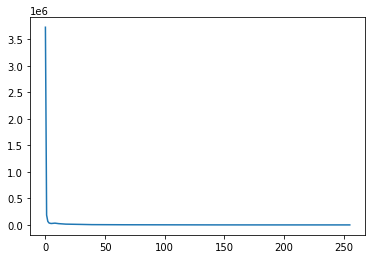

In [9]:
hist_values = cv2.calcHist(
    [dark_horse], channels=[0], mask=None, histSize=[256], ranges=[0, 256]
)
# dark horse has very little blue, lot of zero as it is black!
plt.plot(hist_values)

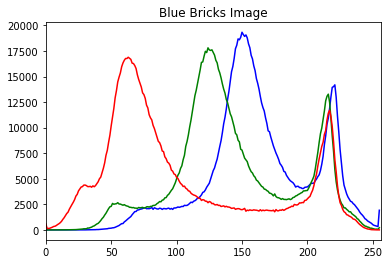

In [10]:
# 3 colours histrogram
img = blue_bricks
color = ("b", "g", "r")
for i, col in enumerate(color):
    histr = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(histr, color=col)
    plt.xlim([0, 256])
plt.title("Blue Bricks Image")
plt.show()

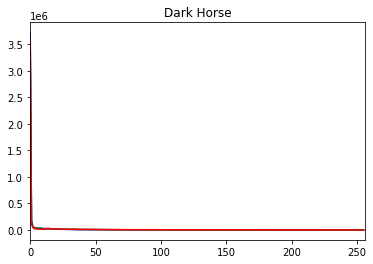

In [11]:
# 3 colours histrogram
img = dark_horse
color = ("b", "g", "r")
for i, col in enumerate(color):
    histr = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(histr, color=col)
    plt.xlim([0, 256])
plt.title("Dark Horse")
plt.show()

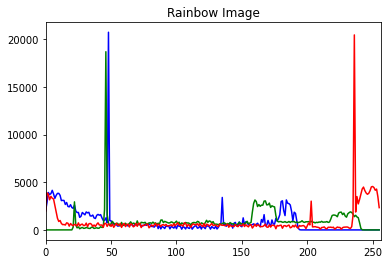

In [12]:
img = rainbow
color = ("b", "g", "r")
for i, col in enumerate(color):
    histr = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(histr, color=col)
    plt.xlim([0, 256])
plt.title("Rainbow Image")
plt.show()

## 1.2 Histogram Equalization

https://en.wikipedia.org/wiki/Histogram_equalization

<img src="https://docs.opencv.org/master/histogram_equalization.png" width=500>

This 'adjusts' the dynamic range of an image, making it spread more evenly accorss the intensity distribution, and thus improving contrast.

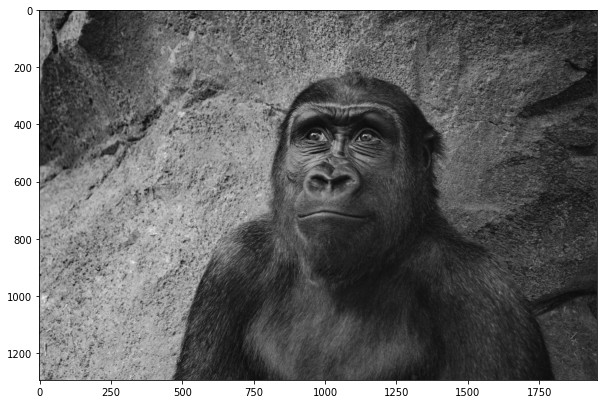

In [13]:
gorilla = cv2.imread("./basic_cv/gorilla.jpg", 0)
display(gorilla, cmap="gray")

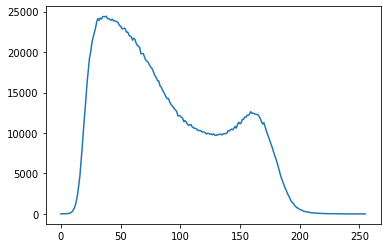

In [14]:
hist_values = cv2.calcHist(
    [gorilla], channels=[0], mask=None, histSize=[256], ranges=[0, 256]
)
plt.plot(hist_values)

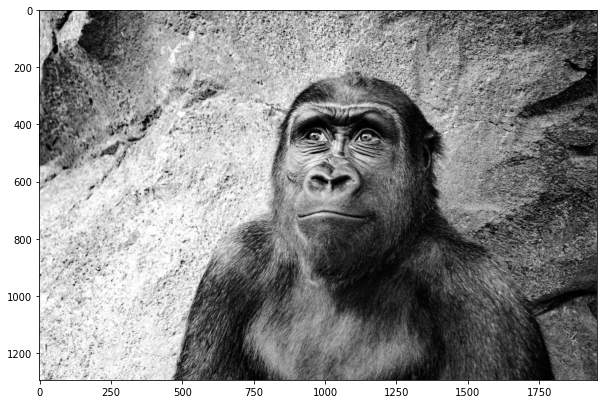

In [15]:
eq_gorilla = cv2.equalizeHist(gorilla)
display(eq_gorilla, cmap="gray")

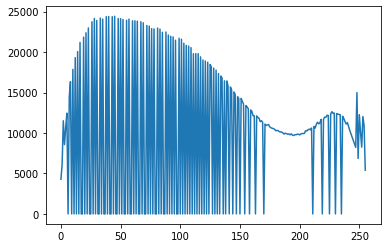

In [16]:
hist_values = cv2.calcHist(
    [eq_gorilla], channels=[0], mask=None, histSize=[256], ranges=[0, 256]
)
plt.plot(hist_values)

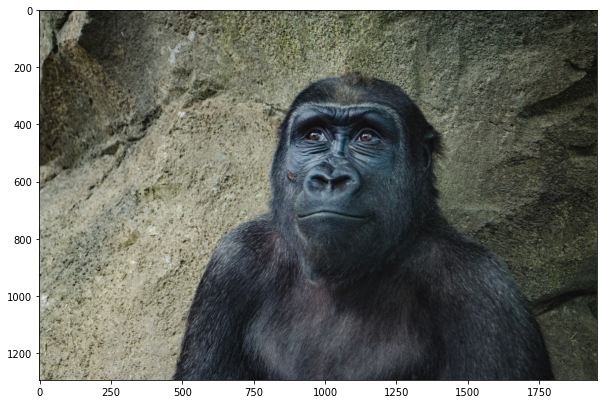

In [17]:
# color image
color_gorilla = cv2.imread("./basic_cv/gorilla.jpg")
show_gorilla = cv2.cvtColor(color_gorilla, cv2.COLOR_BGR2RGB)
# Convert to HSV colorspace
hsv = cv2.cvtColor(color_gorilla, cv2.COLOR_BGR2HSV)
display(show_gorilla)

In [18]:
# Grab V channel
# 0 is hue, 1 is saturation, 2 is color value
hsv[:, :, 2]

array([[127, 121, 115, ...,  43,  42,  42],
       [121, 124, 123, ...,  47,  49,  51],
       [118, 129, 131, ...,  47,  50,  53],
       ...,
       [196, 198, 185, ...,  55,  55,  55],
       [184, 185, 182, ...,  51,  52,  53],
       [174, 170, 173, ...,  49,  50,  50]], dtype=uint8)

In [19]:
# work with hsv
hsv[:, :, 2] = cv2.equalizeHist(hsv[:, :, 2])

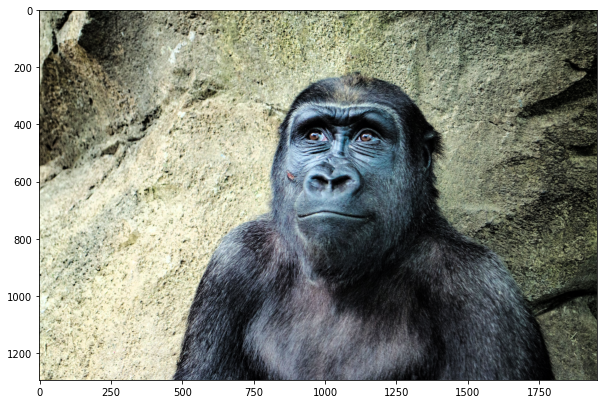

In [20]:
# Convert back to RGB to visualize
eq_color_gorilla = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
display(eq_color_gorilla)

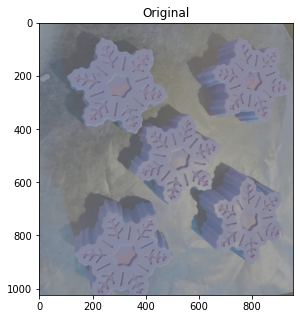

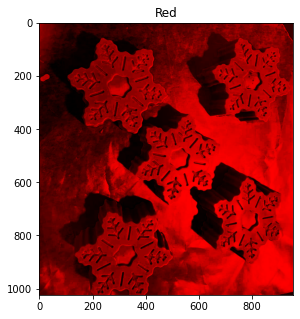

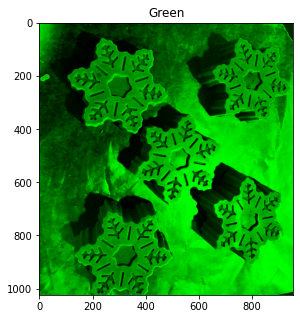

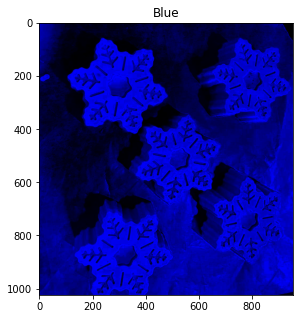

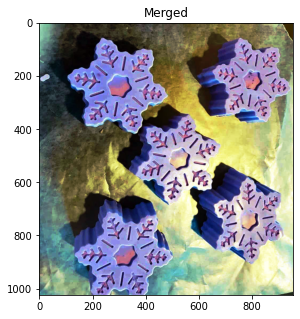

In [23]:
# equalize 3 different colors
img = cv2.imread("soaps.jpeg")
imshow("Original", img, size=5)

# Equalize our Histogramm Default color format is BGR
red = cv2.equalizeHist(img[:, :, 2])
green = cv2.equalizeHist(img[:, :, 1])
blue = cv2.equalizeHist(img[:, :, 0])

# create empty image with same shape as that of src image
red_img = np.zeros(img.shape)
red_img[:, :, 2] = red
red_img = np.array(red_img, dtype=np.uint8)
imshow("Red", red_img, size=5)

green_img = np.zeros(img.shape)
green_img[:, :, 1] = green
green_img = np.array(green_img, dtype=np.uint8)
imshow("Green", green_img, size=5)

blue_img = np.zeros(img.shape)
blue_img[:, :, 0] = blue
blue_img = np.array(blue_img, dtype=np.uint8)
imshow("Blue", blue_img, size=5)

merged = cv2.merge([blue, green, red])
imshow("Merged", merged, size=5)

# 2) Obtaining dominant colors through KMeans Clustering

In [ ]:
def centroidHistogram(clt):
    # Create a histrogram for the clusters based on the pixels in each cluster
    # Get the labels for each cluster
    numLabels = np.arange(0, len(np.unique(clt.labels_)) + 1)

    # Create our histogram
    hist, _ = np.histogram(clt.labels_, bins=numLabels)

    # normalize the histogram, so that it sums to one
    hist = hist.astype("float")
    hist /= hist.sum()
    return hist


def plotColors(hist, centroids):
    # Create our blank barchart
    bar = np.zeros((100, 500, 3), dtype="uint8")
    x_start = 0
    # iterate over the percentage and dominant color of each cluster
    for percent, color in zip(hist, centroids):
        # plot the relative percentage of each cluster
        end = x_start + (percent * 500)
        cv2.rectangle(
            bar, (int(x_start), 0), (int(end), 100), color.astype("uint8").tolist(), -1
        )
        x_start = end
    return bar

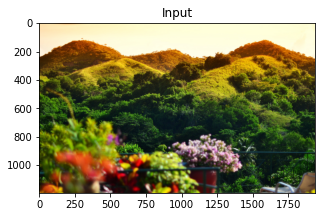

(1194, 1936, 3)
(2311584, 3)


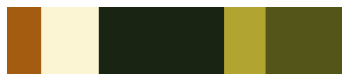

In [ ]:
image = cv2.imread("images/tobago.jpg")
imshow("Input", image)

# We reshape our image into a list of RGB pixels
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(image.shape)
image = image.reshape((image.shape[0] * image.shape[1], 3))
print(image.shape)

number_of_clusters = 5
clt = KMeans(number_of_clusters)
clt.fit(image)

hist = centroidHistogram(clt)
bar = plotColors(hist, clt.cluster_centers_)

# show our color bart
plt.figure()
plt.axis("off")
plt.imshow(bar)
plt.show()

# 3) Structural Similarity

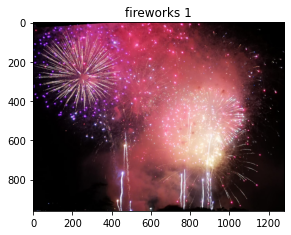

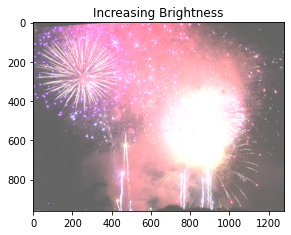

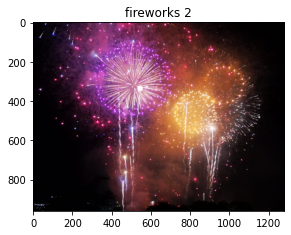

In [ ]:
def mse(image1, image2):
    # Images must be of the same dimension
    error = np.sum((image1.astype("float") - image2.astype("float")) ** 2)
    error /= float(image1.shape[0] * image1.shape[1])
    return error


def compare(image1, image2):
    image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
    print("MSE = {:.2f}".format(mse(image1, image2)))
    print("SS = {:.2f}".format(structural_similarity(image1, image2)))


fireworks1 = cv2.imread("images/fireworks.jpeg")
fireworks2 = cv2.imread("images/fireworks2.jpeg")
M = np.ones(fireworks1.shape, dtype="uint8") * 100
fireworks1b = cv2.add(fireworks1, M)

imshow("fireworks 1", fireworks1, size=6)
imshow("Increasing Brightness", fireworks1b, size=6)
imshow("fireworks 2", fireworks2, size=6)

In [ ]:
compare(fireworks1, fireworks1)
compare(fireworks1, fireworks2)
compare(fireworks1, fireworks1b)
compare(fireworks2, fireworks1b)

MSE = 0.00
SS = 1.00
MSE = 2125.41
SS = 0.48
MSE = 8809.38
SS = 0.52
MSE = 13418.54
SS = 0.19
